# WOCHE 1 - EDA: Explorative Datenanalyse

## Schritt 1: Datensätze laden — Ergebnis & Analyse

In [1]:
# ============================================================
# WOCHE 1 - EDA: Explorative Datenanalyse
# MIST TimeSeries Projekt
# ============================================================


In [2]:
# --- Bibliotheken importieren ---
import pandas as pd                      # Datenverarbeitung
import numpy as np                       # Mathematische Operationen
import matplotlib.pyplot as plt          # Visualisierung
import matplotlib.dates as mdates        # Datumsformatierung für Plots
import seaborn as sns # Erweiterte Visualisierung


In [3]:
# --- Plot-Stil setzen ---
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [4]:
# --- Pfade definieren ---
# Wir sind im Ordner /notebooks, Daten sind in /data
DATA_RAW  = "../data/raw/"
DATA_PROC = "../data/processed/"
DATA_PLOT = "../data/plots/"

# --- CSV Dateien laden ---
df_sales   = pd.read_csv(DATA_RAW + "timeseries.csv")
df_oil     = pd.read_csv(DATA_RAW + "oil.csv")
df_holiday = pd.read_csv(DATA_RAW + "holidays.csv")
df_stores  = pd.read_csv(DATA_RAW + "stores.csv")


In [5]:
# --- Ersten Überblick ausgeben ---
print("=" * 50)
print("TIMESERIES - Verkaufsdaten")
print("=" * 50)
print(f"Zeilen: {df_sales.shape[0]}, Spalten: {df_sales.shape[1]}")
print(df_sales.head())

print("\n" + "=" * 50)
print("OIL - Ölpreise")
print("=" * 50)
print(f"Zeilen: {df_oil.shape[0]}, Spalten: {df_oil.shape[1]}")
print(df_oil.head())

print("\n" + "=" * 50)
print("HOLIDAYS - Feiertage")
print("=" * 50)
print(f"Zeilen: {df_holiday.shape[0]}, Spalten: {df_holiday.shape[1]}")
print(df_holiday.head())

print("\n" + "=" * 50)
print("STORES - Filialen")
print("=" * 50)
print(f"Zeilen: {df_stores.shape[0]}, Spalten: {df_stores.shape[1]}")
print(df_stores.head())

TIMESERIES - Verkaufsdaten
Zeilen: 452, Spalten: 2
         date  unit_sales
0  2013-01-02       582.0
1  2013-01-03       310.0
2  2013-01-04       338.0
3  2013-01-05       654.0
4  2013-01-06       979.0

OIL - Ölpreise
Zeilen: 1218, Spalten: 2
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20

HOLIDAYS - Feiertage
Zeilen: 350, Spalten: 4
         date    locale locale_name                    description
0  2012-03-02     Local       Manta             Fundacion de Manta
1  2012-04-01  Regional    Cotopaxi  Provincializacion de Cotopaxi
2  2012-04-12     Local      Cuenca            Fundacion de Cuenca
3  2012-04-14     Local    Libertad      Cantonizacion de Libertad
4  2012-04-21     Local    Riobamba      Cantonizacion de Riobamba

STORES - Filialen
Zeilen: 54, Spalten: 3
   store_nbr           city                          region
0          1          Quito                   

### Ergebnis

| Datei | Zeilen | Spalten | Inhalt |
|---|---|---|---|
| `timeseries.csv` | 452 | 2 | Tägliche Verkaufszahlen (`date`, `unit_sales`) |
| `oil.csv` | 1.218 | 2 | Tägliche Ölpreise (`date`, `dcoilwtico`) |
| `holidays.csv` | 350 | 4 | Feiertage mit Typ und Region |
| `stores.csv` | 54 | 3 | Filialdaten mit Stadt und Region |

### Analyse

**timeseries.csv:** Der Datensatz umfasst 452 Einträge mit täglichen Verkaufszahlen.
Die Spalte `date` liegt als Text-String vor und muss in ein Datetime-Format konvertiert werden.
Die Verkaufswerte (`unit_sales`) bewegen sich im ersten sichtbaren Bereich zwischen 310 und 979 Einheiten.

**oil.csv:** Der Ölpreis-Datensatz ist mit 1.218 Einträgen deutlich umfangreicher als die Verkaufsdaten.
Bereits in der ersten Zeile (01.01.2013) ist ein fehlender Wert (`NaN`) sichtbar.
Dies ist auf Wochenenden und Feiertage zurückzuführen, an denen der Ölmarkt geschlossen ist.

**holidays.csv:** Feiertage sind in drei Ebenen klassifiziert: `Local`, `Regional` und `National`.
Diese Unterscheidung ist für das spätere Feature Engineering relevant, da nationale Feiertage
einen stärkeren Einfluss auf das Kaufverhalten haben als lokale Ereignisse.

**stores.csv:** Der Datensatz enthält 54 Filialen aus verschiedenen Städten und Regionen Ecuadors.
Da `timeseries.csv` bereits auf eine einzelne Filiale/Produkt-Kombination reduziert wurde,
dient `stores.csv` primär als Kontextinformation.

### Empfehlung

1. **Datum-Konvertierung:** Alle `date`-Spalten müssen von `object` (String) in `datetime64` umgewandelt werden.
2. **Fehlende Ölpreis-Werte:** Die `NaN`-Werte in `oil.csv` sind durch lineare Interpolation zu füllen,
   da es sich um Marktschließungen handelt — kein echter Datenverlust.
3. **Feiertags-Filterung:** Für den Modellierungszeitraum (2013–2014) sind nur Feiertage
   innerhalb dieses Zeitraums relevant. Der Datensatz beginnt bereits 2012.
4. **Fokus der Analyse:** `timeseries.csv` ist die Kernzeitreihe. Alle anderen Datensätze
   werden als exogene Einflussfaktoren im Feature Engineering eingesetzt.

## Schritt 2: Datenbereinigung — Fehlende Werte & Zeitraum

In [6]:
# ============================================================
# SCHRITT 2: Datentypen korrigieren & Zeitreihe vorbereiten
# ============================================================

# --- Datum-Spalten in echtes Datetime-Format umwandeln ---
# Warum? Python muss wissen dass "2013-01-02" ein Datum ist,
# nicht einfach ein Text. Sonst können wir nicht nach Zeit filtern,
# plotten oder Zeitreihen-Operationen durchführen.
df_sales['date']   = pd.to_datetime(df_sales['date'])
df_oil['date']     = pd.to_datetime(df_oil['date'])
df_holiday['date'] = pd.to_datetime(df_holiday['date'])


In [7]:
# --- Datum als Index setzen (Standard für Zeitreihen) ---
df_sales = df_sales.set_index('date')
df_oil   = df_oil.set_index('date')


In [8]:
# ============================================================
# SCHRITT 3: Fehlende Werte analysieren
# ============================================================

print("=" * 50)
print("FEHLENDE WERTE - Übersicht")
print("=" * 50)

print("\n📦 Verkaufsdaten (df_sales):")
print(df_sales.isnull().sum())

print("\n🛢️  Ölpreise (df_oil):")
print(df_oil.isnull().sum())
print(f"   → Anzahl NaN: {df_oil['dcoilwtico'].isnull().sum()} von {len(df_oil)} Tagen")

print("\n🎉 Feiertage (df_holiday):")
print(df_holiday.isnull().sum())

print("\n🏪 Filialen (df_stores):")
print(df_stores.isnull().sum())


FEHLENDE WERTE - Übersicht

📦 Verkaufsdaten (df_sales):
unit_sales    0
dtype: int64

🛢️  Ölpreise (df_oil):
dcoilwtico    43
dtype: int64
   → Anzahl NaN: 43 von 1218 Tagen

🎉 Feiertage (df_holiday):
date           0
locale         0
locale_name    0
description    0
dtype: int64

🏪 Filialen (df_stores):
store_nbr    0
city         0
region       0
dtype: int64


In [9]:
# ============================================================
# SCHRITT 4: Zeitraum & Grundstatistik prüfen
# ============================================================

print("\n" + "=" * 50)
print("ZEITRAUM & STATISTIK")
print("=" * 50)

print(f"\n📅 Verkaufsdaten von: {df_sales.index.min().date()} bis {df_sales.index.max().date()}")
print(f"   Anzahl Tage im Datensatz: {len(df_sales)}")

# Wie viele Tage sollten es theoretisch sein?
expected_days = (df_sales.index.max() - df_sales.index.min()).days + 1
print(f"   Erwartete Tage (lückenlos): {expected_days}")
print(f"   Fehlende Tage: {expected_days - len(df_sales)}")

print(f"\n📊 Verkaufszahlen - Statistik:")
print(df_sales['unit_sales'].describe().round(2))

print(f"\n🛢️  Ölpreise von: {df_oil.index.min().date()} bis {df_oil.index.max().date()}")
print(f"   Statistik Ölpreis:")
print(df_oil['dcoilwtico'].describe().round(2))


ZEITRAUM & STATISTIK

📅 Verkaufsdaten von: 2013-01-02 bis 2014-03-31
   Anzahl Tage im Datensatz: 452
   Erwartete Tage (lückenlos): 454
   Fehlende Tage: 2

📊 Verkaufszahlen - Statistik:
count     452.00
mean      480.09
std       170.84
min         4.00
25%       358.00
50%       445.50
75%       578.25
max      1203.00
Name: unit_sales, dtype: float64

🛢️  Ölpreise von: 2013-01-01 bis 2017-08-31
   Statistik Ölpreis:
count    1175.00
mean       67.71
std        25.63
min        26.19
25%        46.40
50%        53.19
75%        95.66
max       110.62
Name: dcoilwtico, dtype: float64


### Ergebnis

**Fehlende Werte:**

| Datensatz | Spalte | Fehlende Werte | Anteil |
|---|---|---|---|
| `timeseries.csv` | `unit_sales` | 0 | 0% |
| `oil.csv` | `dcoilwtico` | 43 | 3.5% |
| `holidays.csv` | alle | 0 | 0% |
| `stores.csv` | alle | 0 | 0% |

**Zeitraum & Vollständigkeit:**

| Kennzahl | Wert |
|---|---|
| Zeitraum Verkaufsdaten | 02.01.2013 – 31.03.2014 |
| Vorhandene Tage | 452 |
| Erwartete Tage (lückenlos) | 454 |
| Fehlende Tage | **2** |

**Verkaufszahlen — Deskriptive Statistik:**

| Kennzahl | Wert |
|---|---|
| Mittelwert | 480 Einheiten/Tag |
| Standardabweichung | 171 Einheiten |
| Minimum | 4 Einheiten |
| Maximum | 1.203 Einheiten |
| Median (50%) | 446 Einheiten |

**Ölpreise:**

| Kennzahl | Wert |
|---|---|
| Zeitraum | 01.01.2013 – 31.08.2017 |
| Fehlende Werte | 43 (Wochenenden/Feiertage) |
| Preisspanne | 26.19 – 110.62 USD/Barrel |
| Mittelwert | 67.71 USD/Barrel |

### Analyse

**Verkaufsdaten:** Die Zeitreihe ist nahezu vollständig. Es fehlen exakt 2 Tage im
Zeitraum 02.01.2013–31.03.2014. Diese fehlenden Tage sind wahrscheinlich auf
Schließtage des Supermarkts zurückzuführen (z.B. Feiertage).
Der Minimalwert von 4 Einheiten ist auffällig niedrig im Vergleich zum Median von
446 — dieser Tag ist ein potenzieller Ausreißer und muss genauer untersucht werden.
Die Standardabweichung von 171 bei einem Mittelwert von 480 deutet auf eine
moderate Streuung hin (~36%), was für Einzelhandelsdaten typisch ist.

**Ölpreise:** Der Datensatz reicht bis 2017, unsere Verkaufsdaten nur bis März 2014.
Dies ist kein Problem — wir verwenden nur den überlappenden Zeitraum.
Der starke Preisrückgang (von ~110 auf ~26 USD) spiegelt den globalen Ölpreisverfall
2014–2016 wider, liegt jedoch außerhalb unseres Modellierungszeitraums.
Die 43 fehlenden Werte (~3.5%) entstehen durch Marktschließungen und sind
methodisch korrekt durch lineare Interpolation zu behandeln.

### Empfehlung

1. **Fehlende Tage in Verkaufsdaten:** Die 2 fehlenden Tage sind zu identifizieren
   und mit dem Wert `0` zu füllen — Schließtage bedeuten null Umsatz, keine
   fehlende Messung.
2. **Ölpreis-Interpolation:** Die 43 NaN-Werte werden mittels linearer Interpolation
   gefüllt. Begründung: Ölpreise ändern sich kontinuierlich — ein linearer Übergang
   zwischen zwei bekannten Werten ist die sachlich korrekte Annahme.
3. **Ausreißer untersuchen:** Der Minimalwert von 4 Einheiten muss im nächsten
   Schritt visuell und statistisch geprüft werden, bevor eine Entscheidung
   (behalten / ersetzen) getroffen wird.
4. **Ölpreis-Datensatz kürzen:** Für unser Modell wird `oil.csv` auf den Zeitraum
   2013–2014 reduziert, um Irrelevantes auszuschließen.


## Schritt 3: Datenbereinigung — Ergebnis & Analyse

In [10]:
# ============================================================
# SCHRITT 3: Datenbereinigung
# ============================================================

# --- 3.1: Fehlende Tage in Verkaufsdaten identifizieren ---
# Wir erstellen einen vollständigen Datumsbereich und prüfen
# welche Tage fehlen

full_date_range = pd.date_range(
    start=df_sales.index.min(),
    end=df_sales.index.max(),
    freq='D'                        # 'D' = täglich
)

# Welche Tage fehlen?
missing_dates = full_date_range.difference(df_sales.index)
print("=" * 50)
print("FEHLENDE TAGE IN VERKAUFSDATEN")
print("=" * 50)
print(f"Fehlende Tage: {list(missing_dates.date)}")


FEHLENDE TAGE IN VERKAUFSDATEN
Fehlende Tage: [datetime.date(2013, 12, 25), datetime.date(2014, 1, 1)]


In [11]:
# --- 3.2: Fehlende Tage mit 0 auffüllen ---
# Begründung: Fehlende Tage = Schließtage = 0 Umsatz
df_sales = df_sales.reindex(full_date_range, fill_value=0)
df_sales.index.name = 'date'

print(f"\n✅ Verkaufsdaten nach Auffüllen: {len(df_sales)} Tage")



✅ Verkaufsdaten nach Auffüllen: 454 Tage


In [12]:
# --- 3.3: Ölpreis - Interpolation fehlender Werte ---
# Lineare Interpolation: Wert zwischen zwei bekannten Punkten
# wird gleichmäßig aufgefüllt
# Beispiel: [93.0, NaN, NaN, 96.0] → [93.0, 94.0, 95.0, 96.0]
df_oil_clean = df_oil.copy()
df_oil_clean['dcoilwtico'] = df_oil_clean['dcoilwtico'].interpolate(method='linear')

# Auf unseren Zeitraum kürzen
df_oil_clean = df_oil_clean.reindex(full_date_range)
df_oil_clean['dcoilwtico'] = df_oil_clean['dcoilwtico'].interpolate(method='linear')

print("\n" + "=" * 50)
print("ÖLPREIS NACH INTERPOLATION")
print("=" * 50)
print(f"Verbleibende NaN-Werte: {df_oil_clean['dcoilwtico'].isnull().sum()}")
print(df_oil_clean.describe().round(2))



ÖLPREIS NACH INTERPOLATION
Verbleibende NaN-Werte: 0
       dcoilwtico
count      454.00
mean        98.13
std          5.14
min         86.65
25%         93.96
50%         97.00
75%        102.36
max        110.62


In [13]:
# --- 3.4: Ausreißer in Verkaufsdaten identifizieren ---
# Methode: Z-Score
# Mathematik: z = (x - mean) / std
# Interpretation: z > 3 bedeutet der Wert liegt mehr als
# 3 Standardabweichungen vom Mittelwert entfernt → Ausreißer

from scipy import stats

z_scores = np.abs(stats.zscore(df_sales['unit_sales']))
outliers = df_sales[z_scores > 3]

print("\n" + "=" * 50)
print("AUSREISSER (Z-Score > 3)")
print("=" * 50)
print(f"Anzahl Ausreißer: {len(outliers)}")
if len(outliers) > 0:
    print(outliers)



AUSREISSER (Z-Score > 3)
Anzahl Ausreißer: 3
            unit_sales
date                  
2013-01-20      1090.0
2014-01-05      1203.0
2014-01-16      1168.0


In [14]:
# --- 3.5: Minimum-Wert lokalisieren ---
print("\n" + "=" * 50)
print("MINIMUM-WERT ANALYSE")
print("=" * 50)
min_day = df_sales['unit_sales'].idxmin()
print(f"Tag mit minimalem Umsatz: {min_day.date()}")
print(f"Umsatz: {df_sales.loc[min_day, 'unit_sales']} Einheiten")
print(f"Wochentag: {min_day.strftime('%A')}")

# Kontext: 3 Tage davor und danach
print(f"\nKontext (±3 Tage):")
print(df_sales.loc[min_day - pd.Timedelta(days=3) :
                   min_day + pd.Timedelta(days=3)])


MINIMUM-WERT ANALYSE
Tag mit minimalem Umsatz: 2013-12-25
Umsatz: 0.0 Einheiten
Wochentag: Wednesday

Kontext (±3 Tage):
            unit_sales
date                  
2013-12-22       985.0
2013-12-23       523.0
2013-12-24       365.0
2013-12-25         0.0
2013-12-26       418.0
2013-12-27       419.0
2013-12-28       499.0


### Ergebnis

**3.1 Fehlende Tage in Verkaufsdaten:**

| Datum | Wochentag | Interpretation |
|---|---|---|
| 25.12.2013 | Mittwoch | Weihnachtstag |
| 01.01.2014 | Mittwoch | Neujahr |

Nach Auffüllen mit Wert `0`: **454 Tage** (vollständige Zeitreihe) ✅

**3.2 Ölpreis nach Interpolation:**

| Kennzahl | Wert |
|---|---|
| Verbleibende NaN-Werte | 0 ✅ |
| Mittelwert | 98.13 USD/Barrel |
| Standardabweichung | 5.14 USD/Barrel |
| Minimum | 86.65 USD/Barrel |
| Maximum | 110.62 USD/Barrel |

**3.3 Ausreißer (Z-Score > 3):**

| Datum | Verkauf (Einheiten) | Kontext |
|---|---|---|
| 20.01.2013 | 1.090 | Früh im Jahr — möglicher Sonderverkauf |
| 05.01.2014 | 1.203 | Kurz nach Neujahr — Nachholkäufe |
| 16.01.2014 | 1.168 | Mitte Januar — mögliche Promotion |

**3.4 Minimum-Wert Analyse — Kontext ±3 Tage:**

| Datum | Einheiten | Bemerkung |
|---|---|---|
| 22.12.2013 | 985 | Vorweihnachtlicher Einkaufspeak |
| 23.12.2013 | 523 | Rückgang |
| 24.12.2013 | 365 | Heiligabend — starker Rückgang |
| **25.12.2013** | **0** | **Weihnachtstag — Schließtag** |
| 26.12.2013 | 418 | Normalisierung |
| 27.12.2013 | 419 | Normalisierung |
| 28.12.2013 | 499 | Normalisierung |

### Analyse

**Fehlende Tage:** Die zwei fehlenden Tage sind eindeutig identifiziert als gesetzliche
Feiertage (Weihnachten und Neujahr). Der Minimalwert von 0 Einheiten am 25.12.2013
bestätigt die Interpretation als Schließtag. Die Auffüllung mit `0` ist sachlich korrekt.

**Ölpreise:** Nach der linearen Interpolation sind keine fehlenden Werte mehr vorhanden.
Der Ölpreis bewegt sich im Modellierungszeitraum 2013–Q1/2014 in einem engen Band
zwischen 86.65 und 110.62 USD/Barrel mit einer geringen Standardabweichung von 5.14.
Dies deutet auf eine relativ stabile Ölpreisphase hin — starke Preisausschläge als
exogener Einflussfaktor sind in diesem Zeitraum nicht zu erwarten.

**Ausreißer:** Es wurden 3 Tage mit einem Z-Score > 3 identifiziert. Alle drei liegen
im Januar (2013 und 2014), was auf saisonale Nachholkäufe nach den Feiertagen
hindeutet. Der Maximalwert von 1.203 Einheiten am 05.01.2014 entspricht dem
2.5-fachen des Medians (446 Einheiten) — ein deutlicher, aber kontextuell
erklärbarer Ausschlag.

### Entscheidung: Ausreißer behalten

Die drei identifizierten Ausreißer werden **nicht entfernt**, sondern beibehalten.
Begründung:
- Sie sind kontextuell erklärbar (Post-Feiertags-Effekt)
- Sie repräsentieren reale Kaufereignisse, keine Messfehler
- ML-Modelle (XGBoost) sind robust gegenüber solchen Ausschlägen
- Das Entfernen würde dem Modell wichtige saisonale Information entziehen

### Empfehlung

1. **Zeitreihe ist bereinigt** und umfasst nun lückenlos 454 Tage. ✅
2. **Nächster Schritt:** Visuelle Analyse der Zeitreihe — Trend, Saisonalität
   und Wochenmuster identifizieren.
3. **Januar-Effekt vormerken:** Der wiederkehrende Verkaufspeak im Januar
   (2013 und 2014) ist

## Exkurs: Z-Score — Mathematischer Hintergrund

### Was ist der Z-Score?

Der Z-Score (auch Standardisierung genannt) misst, wie weit ein einzelner Wert
vom Mittelwert der Gesamtverteilung entfernt ist — ausgedrückt in Einheiten der
Standardabweichung.

### Formel

$$z = \frac{x - \mu}{\sigma}$$

| Symbol | Bedeutung | In unserem Beispiel |
|---|---|---|
| `x` | Einzelner Messwert | Tagesverkauf z.B. 1.203 Einheiten |
| `μ` (mu) | Mittelwert aller Werte | 480 Einheiten/Tag |
| `σ` (sigma) | Standardabweichung | 171 Einheiten |
| `z` | Resultat: Z-Score | (1203 - 480) / 171 = **4.23** |

### Interpretation

| Z-Score | Bedeutung | Entscheidung |
|---|---|---|
| 0 | Exakt der Mittelwert | Normal |
| ±1 | 68% aller Werte liegen in diesem Bereich | Normal |
| ±2 | 95% aller Werte liegen in diesem Bereich | Normal |
| ±3 | 99.7% aller Werte liegen in diesem Bereich | **Grenzwert** |
| > 3 | Weniger als 0.3% aller Werte | **Ausreißer** |

Ein Z-Score von 4.23 bedeutet: Dieser Wert liegt 4.23 Standardabweichungen
über dem Mittelwert. Die Wahrscheinlichkeit, einen solchen Wert zufällig zu
beobachten, beträgt weniger als 0.001% — er ist statistisch außergewöhnlich.

### Warum Z-Score und nicht einfach ein fixer Grenzwert?

Ein fixer Grenzwert (z.B. "alles über 1.000 ist ein Ausreißer") ist
datensatzabhängig und nicht übertragbar. Der Z-Score passt sich automatisch
an die Verteilung des jeweiligen Datensatzes an — er ist **relativ** zum
Datensatz, nicht absolut.

**Analogie aus dem Ingenieurwesen:** Der Z-Score funktioniert wie eine
Toleranzangabe in der Fertigung. Nicht "mehr als 5mm Abweichung ist Ausschuss",
sondern "mehr als 3-fache Standardtoleranz ist Ausschuss" — relativ zur
Fertigungsgenauigkeit der Maschine.

### Grenzen des Z-Scores

- Setzt eine **Normalverteilung** voraus — bei stark schiefen Verteilungen
  ist er weniger zuverlässig.
- Bei kleinen Datensätzen (< 30 Werte) ist er anfällig für Verzerrungen.
- Alternative bei nicht-normalverteilten Daten: **IQR-Methode**
  (Interquartilsabstand), die wir bei Bedarf in Woche 2 einsetzen können.

## Schritt 4: Visualisierung der Zeitreihe — Ergebnis & Analyse

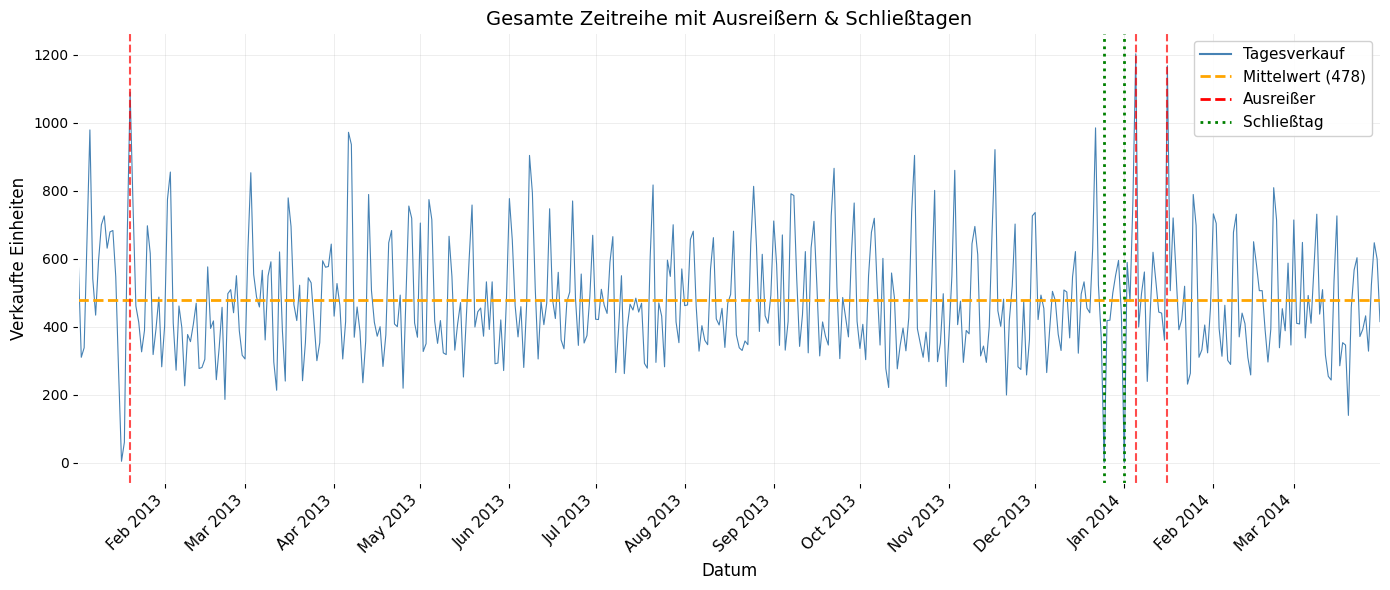

✅ Plot 1 gespeichert


In [15]:
# ============================================================
# PLOT 1: Gesamte Zeitreihe
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# Farb-Fix für Windows 125% Skalierung
matplotlib.rcParams['text.color']        = 'black'
matplotlib.rcParams['axes.labelcolor']   = 'black'
matplotlib.rcParams['xtick.color']       = 'black'
matplotlib.rcParams['ytick.color']       = 'black'
matplotlib.rcParams['figure.facecolor']  = 'white'
matplotlib.rcParams['axes.facecolor']    = 'white'
matplotlib.rcParams['font.family']       = 'DejaVu Sans'

date_min = df_sales.index.min()
date_max = df_sales.index.max()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_sales.index, df_sales['unit_sales'],
        color='steelblue', linewidth=0.8)
ax.axhline(df_sales['unit_sales'].mean(),
           color='orange', linestyle='--', linewidth=2)
for d in ['2013-01-20', '2014-01-05', '2014-01-16']:
    ax.axvline(pd.Timestamp(d), color='red',
               linestyle='--', alpha=0.7, linewidth=1.5)
for d in ['2013-12-25', '2014-01-01']:
    ax.axvline(pd.Timestamp(d), color='green',
               linestyle=':', linewidth=2)

ax.set_xlim(date_min, date_max)
ax.set_title('Gesamte Zeitreihe mit Ausreißern & Schließtagen', fontsize=14)
ax.set_ylabel('Verkaufte Einheiten', fontsize=12)
ax.set_xlabel('Datum', fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

ax.legend(handles=[
    Line2D([0],[0], color='steelblue', lw=1.5, label='Tagesverkauf'),
    Line2D([0],[0], color='orange', ls='--', lw=2,
           label=f'Mittelwert ({df_sales["unit_sales"].mean():.0f})'),
    Line2D([0],[0], color='red',   ls='--', lw=2, label='Ausreißer'),
    Line2D([0],[0], color='green', ls=':',  lw=2, label='Schließtag'),
], loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('../data/plots/plot1_zeitreihe.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 gespeichert")

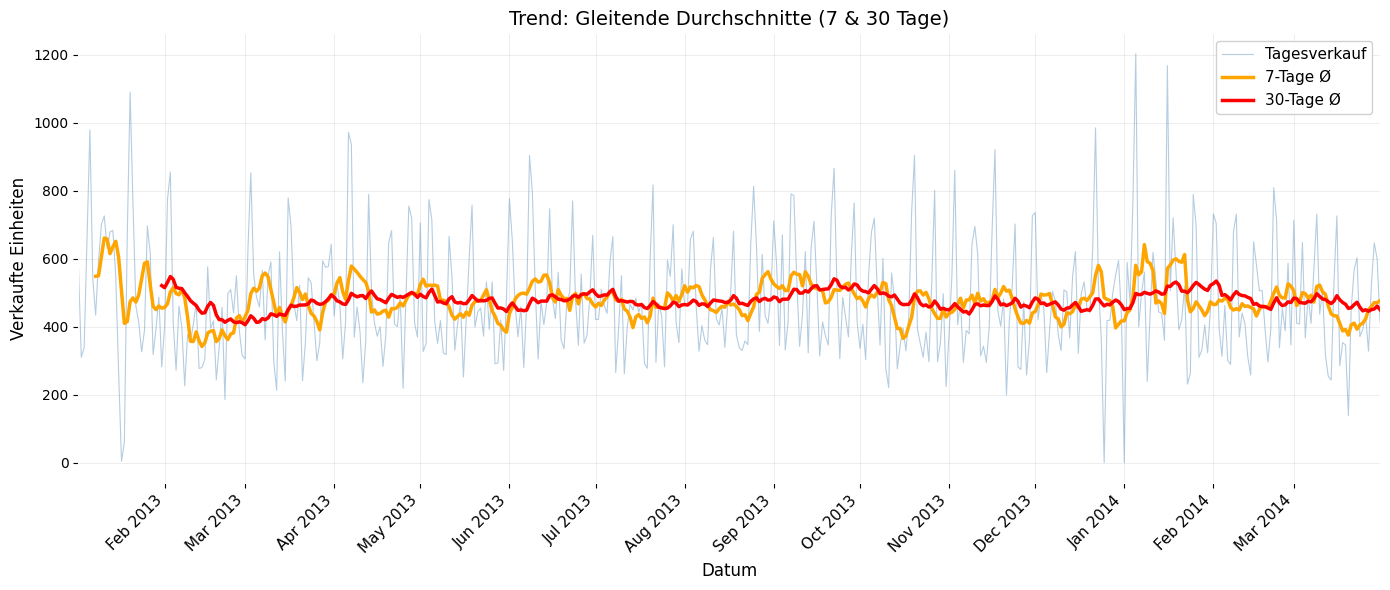

✅ Plot 2 gespeichert


In [16]:
# ============================================================
# PLOT 2: Gleitende Durchschnitte (Trend)
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['text.color']       = 'black'
matplotlib.rcParams['axes.labelcolor']  = 'black'
matplotlib.rcParams['xtick.color']      = 'black'
matplotlib.rcParams['ytick.color']      = 'black'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
matplotlib.rcParams['font.family']      = 'DejaVu Sans'

date_min = df_sales.index.min()
date_max = df_sales.index.max()

# Gleitende Durchschnitte berechnen
# Mathematik: rolling(7).mean() = Mittelwert der letzten 7 Tage
# Effekt: Kurzfristiges Rauschen wird geglättet → Trend sichtbar
r7  = df_sales['unit_sales'].rolling(window=7).mean()
r30 = df_sales['unit_sales'].rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_sales.index, df_sales['unit_sales'],
        color='steelblue', alpha=0.4, linewidth=0.8, label='Tagesverkauf')
ax.plot(df_sales.index, r7,
        color='orange', linewidth=2.5, label='7-Tage Ø')
ax.plot(df_sales.index, r30,
        color='red', linewidth=2.5, label='30-Tage Ø')

ax.set_xlim(date_min, date_max)
ax.set_title('Trend: Gleitende Durchschnitte (7 & 30 Tage)', fontsize=14)
ax.set_ylabel('Verkaufte Einheiten', fontsize=12)
ax.set_xlabel('Datum', fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('../data/plot2_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 gespeichert")

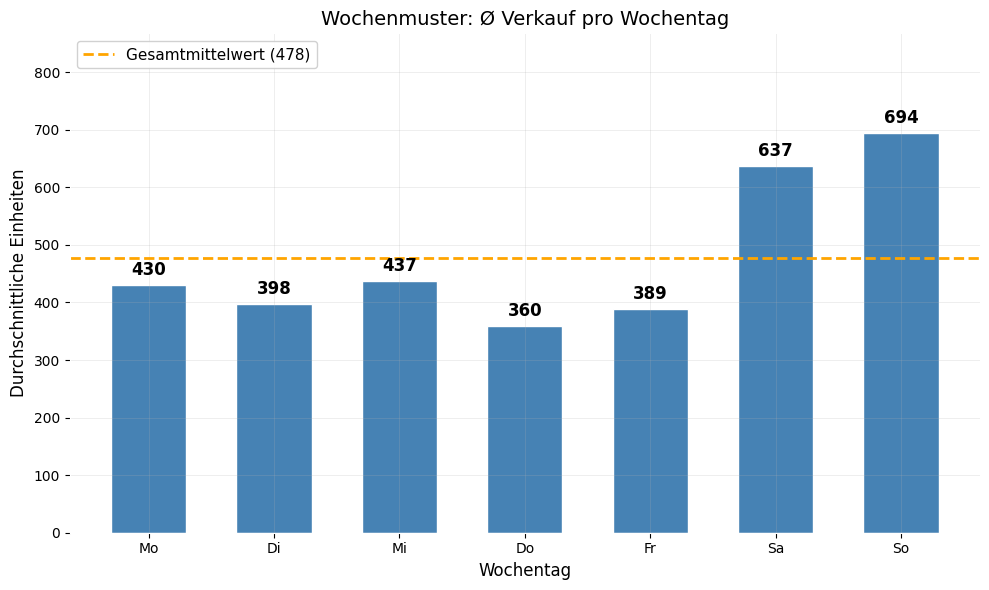

✅ Plot 3 gespeichert


In [17]:
# ============================================================
# PLOT 3: Wochenmuster
# ============================================================
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['text.color']       = 'black'
matplotlib.rcParams['axes.labelcolor']  = 'black'
matplotlib.rcParams['xtick.color']      = 'black'
matplotlib.rcParams['ytick.color']      = 'black'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
matplotlib.rcParams['font.family']      = 'DejaVu Sans'

weekday_order  = ['Monday','Tuesday','Wednesday',
                  'Thursday','Friday','Saturday','Sunday']
weekday_labels = ['Mo','Di','Mi','Do','Fr','Sa','So']

weekday_avg = (df_sales['unit_sales']
               .groupby(df_sales.index.day_name())
               .mean()
               .reindex(weekday_order))

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(weekday_labels, weekday_avg.values,
              color='steelblue', edgecolor='white', width=0.6)

# Zahlenwerte über jeden Balken
for bar, val in zip(bars, weekday_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'{val:.0f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            color='black')

ax.axhline(df_sales['unit_sales'].mean(),
           color='orange', linestyle='--', linewidth=2,
           label=f'Gesamtmittelwert ({df_sales["unit_sales"].mean():.0f})')

ax.set_ylim(0, weekday_avg.max() * 1.25)
ax.set_title('Wochenmuster: Ø Verkauf pro Wochentag', fontsize=14)
ax.set_ylabel('Durchschnittliche Einheiten', fontsize=12)
ax.set_xlabel('Wochentag', fontsize=12)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('../data/plot3_wochenmuster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 gespeichert")

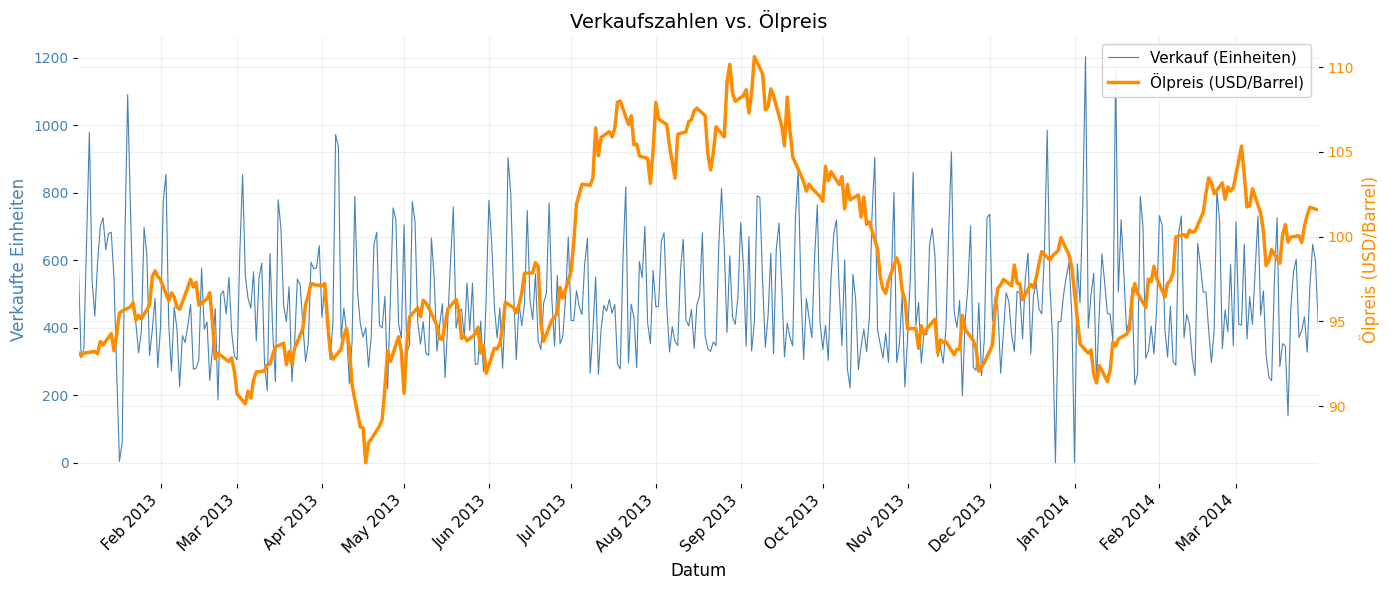

✅ Plot 4 gespeichert


In [18]:
# ============================================================
# PLOT 4: Verkaufszahlen vs. Ölpreis
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['text.color']       = 'black'
matplotlib.rcParams['axes.labelcolor']  = 'black'
matplotlib.rcParams['xtick.color']      = 'black'
matplotlib.rcParams['ytick.color']      = 'black'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
matplotlib.rcParams['font.family']      = 'DejaVu Sans'

date_min = df_sales.index.min()
date_max = df_sales.index.max()

fig, ax = plt.subplots(figsize=(14, 6))
ax2 = ax.twinx()  # zweite Y-Achse rechts

l1, = ax.plot(df_sales.index, df_sales['unit_sales'],
              color='steelblue', linewidth=0.8, label='Verkauf (Einheiten)')
l2, = ax2.plot(df_oil_clean.index, df_oil_clean['dcoilwtico'],
               color='darkorange', linewidth=2.5, label='Ölpreis (USD/Barrel)')

ax.set_xlim(date_min, date_max)
ax.set_title('Verkaufszahlen vs. Ölpreis', fontsize=14)
ax.set_ylabel('Verkaufte Einheiten', fontsize=12, color='steelblue')
ax2.set_ylabel('Ölpreis (USD/Barrel)', fontsize=12, color='darkorange')
ax.set_xlabel('Datum', fontsize=12)

ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

ax.legend(handles=[l1, l2], loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('../data/plot4_oel_vs_verkauf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 gespeichert")

### Plot 1: Gesamte Zeitreihe

**Beobachtungen:**
- Verkaufszahlen schwanken stark zwischen ~150 und ~1.200 Einheiten/Tag
- Kein erkennbarer langfristiger Aufwärtstrend — die Zeitreihe bewegt
  sich stabil um den Mittelwert von 478 Einheiten
- Zwei Schließtage klar erkennbar: 25.12.2013 (Weihnachten) und
  01.01.2014 (Neujahr) — Verkauf fällt auf 0
- Drei Ausreißer sichtbar: Januar 2013 und Januar 2014 —
  Post-Feiertags-Kaufeffekt

### Plot 2: Gleitende Durchschnitte (7 & 30 Tage)

**Beobachtungen:**
- Der 7-Tage-Durchschnitt (orange) glättet das tägliche Rauschen
  sichtbar und zeigt kurzfristige Schwankungszyklen
- Der 30-Tage-Durchschnitt (rot) verläuft nahezu horizontal bei
  ~480 Einheiten — **kein signifikanter Trend** im Betrachtungszeitraum
- Leichter Rückgang zu Beginn (Jan–Feb 2013), danach stabile Phase
- Der Anstieg gegen Ende (Jan–Feb 2014) entspricht den
  Post-Neujahrs-Ausreißern

### Plot 3: Wochenmuster

**Beobachtungen:**

| Wochentag | Ø Einheiten | vs. Mittelwert (478) |
|---|---|---|
| Mo | 430 | -10% |
| Di | 398 | -17% |
| Mi | 437 | -9% |
| Do | 360 | -25% |
| Fr | 389 | -19% |
| Sa | 637 | +33% |
| So | 694 | +45% |

- **Samstag und Sonntag** liegen deutlich über dem Gesamtmittelwert
- **Donnerstag** ist der schwächste Verkaufstag (360 Einheiten)
- Der Unterschied zwischen stärkstem (So: 694) und schwächstem
  Tag (Do: 360) beträgt **334 Einheiten = 93%** — ein sehr starkes Signal
- Alle Werktage liegen unter dem Gesamtmittelwert

### Plot 4: Verkaufszahlen vs. Ölpreis

**Beobachtungen:**
- Der Ölpreis (orange) zeigt einen klaren Anstieg von ~93 USD (Jan 2013)
  auf ~110 USD (Sep 2013), gefolgt von einem Rückgang auf ~90 USD
- Die Verkaufszahlen (blau) folgen diesem Muster **nicht erkennbar**
- Keine visuelle Korrelation zwischen Ölpreis und Tagesverkauf
  im Betrachtungszeitraum 2013–Q1/2014

### Gesamtfazit & Implikationen für das Modell

| Befund | Implikation |
|---|---|
| Kein Trend | Kein Trend-Term im Modell nötig |
| Starkes Wochenmuster | `day_of_week` → wichtigstes Feature |
| Schließtage = 0 | Feiertags-Feature einbauen |
| Keine Ölpreis-Korrelation | Ölpreis mit Vorsicht einsetzen |
| Hohe Volatilität | Robuste Modelle bevorzugen (XGBoost) |

### Empfehlung

1. **Nächster Schritt:** Saisonale Zerlegung (Decomposition) und
   Stationaritätstest (ADF-Test) — mathematische Bestätigung
   der visuellen Beobachtungen.
2. **Wochentag** als wichtigstes endogenes Feature für Woche 2 vormerken.
3. **Feiertags-Feature** aus `holidays.csv` für Feature Engineering
   vorbereiten.

## Schritt 5: Saisonale Zerlegung & Stationaritätstest — Ergebnis & Analyse

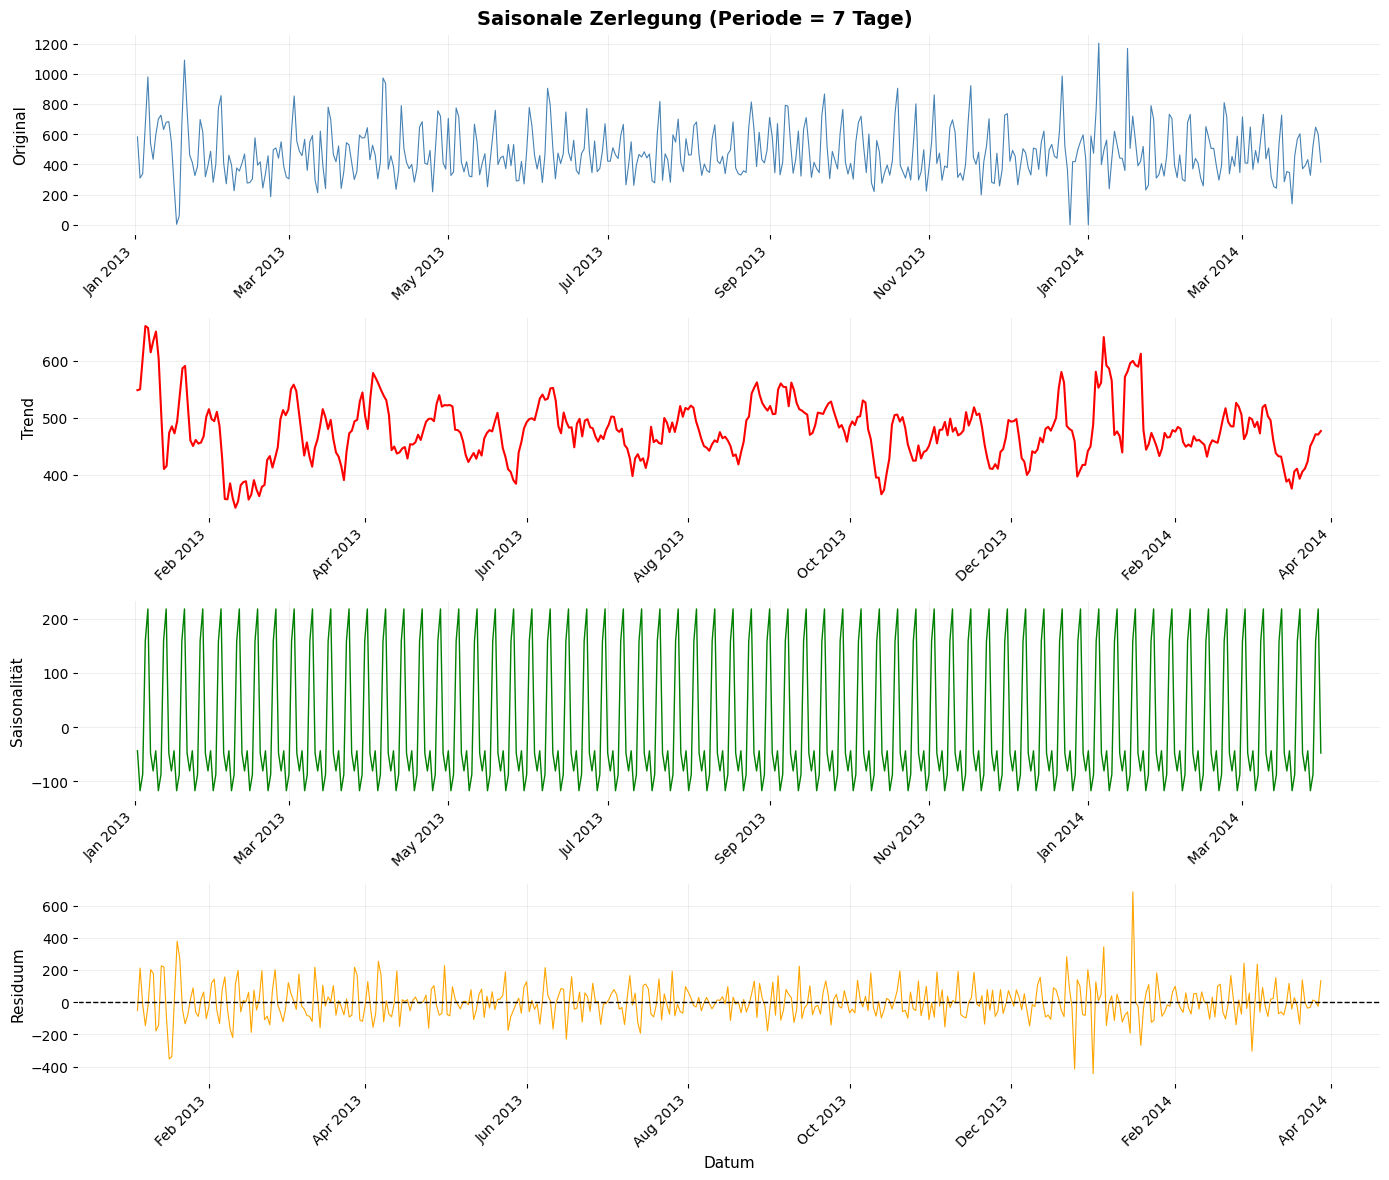

✅ Zerlegung gespeichert

ADF-TEST: Stationaritätstest
ADF-Statistik : -5.3438
p-Wert        : 0.0000
Kritische Werte:
   1%: -3.4455
   5%: -2.8682
   10%: -2.5703

── Interpretation ──
✅ p-Wert < 0.05 → Zeitreihe ist STATIONÄR
   ARIMA kann direkt angewendet werden


In [19]:
# ============================================================
# SCHRITT 5: Saisonale Zerlegung & Stationaritätstest
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

matplotlib.rcParams['text.color']       = 'black'
matplotlib.rcParams['axes.labelcolor']  = 'black'
matplotlib.rcParams['xtick.color']      = 'black'
matplotlib.rcParams['ytick.color']      = 'black'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
matplotlib.rcParams['font.family']      = 'DejaVu Sans'

# ── 5.1: Saisonale Zerlegung ──────────────────────────────
# Mathematik: Zeitreihe = Trend + Saisonalität + Residuum
# period=7 → wir erwarten ein 7-Tage (Wochen) Muster
# model='additive' → Komponenten werden addiert (nicht multipliziert)
# Wann additiv? Wenn Schwankungen konstant bleiben (nicht mit Trend wachsen)

decomposition = seasonal_decompose(
    df_sales['unit_sales'],
    model='additive',
    period=7           # 7 = wöchentliche Saisonalität
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Saisonale Zerlegung (Periode = 7 Tage)',
             fontsize=14, fontweight='bold')

# Original
axes[0].plot(decomposition.observed, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Original', fontsize=11)
axes[0].set_xlabel('')

# Trend
axes[1].plot(decomposition.trend, color='red', linewidth=1.5)
axes[1].set_ylabel('Trend', fontsize=11)

# Saisonalität
axes[2].plot(decomposition.seasonal, color='green', linewidth=1)
axes[2].set_ylabel('Saisonalität', fontsize=11)

# Residuum
axes[3].plot(decomposition.resid, color='orange', linewidth=0.8)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residuum', fontsize=11)
axes[3].set_xlabel('Datum', fontsize=11)

for ax in axes:
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig('../data/plot5_zerlegung.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Zerlegung gespeichert")

# ── 5.2: ADF-Test (Augmented Dickey-Fuller) ───────────────
# Testet ob eine Zeitreihe stationär ist
# Stationär = Mittelwert und Varianz ändern sich nicht über Zeit
# Warum wichtig? ARIMA setzt Stationarität voraus!
#
# H0 (Nullhypothese):  Zeitreihe ist NICHT stationär
# H1 (Alternativ):     Zeitreihe IST stationär
# Entscheidung: p-Wert < 0.05 → H0 ablehnen → stationär

result = adfuller(df_sales['unit_sales'].dropna())

print("\n" + "=" * 50)
print("ADF-TEST: Stationaritätstest")
print("=" * 50)
print(f"ADF-Statistik : {result[0]:.4f}")
print(f"p-Wert        : {result[1]:.4f}")
print(f"Kritische Werte:")
for key, val in result[4].items():
    print(f"   {key}: {val:.4f}")

print("\n── Interpretation ──")
if result[1] < 0.05:
    print("✅ p-Wert < 0.05 → Zeitreihe ist STATIONÄR")
    print("   ARIMA kann direkt angewendet werden")
else:
    print("⚠️  p-Wert >= 0.05 → Zeitreihe ist NICHT stationär")
    print("   Differenzierung notwendig (d > 0 in ARIMA)")

### 5.1 Saisonale Zerlegung (period=7)

Die Zeitreihe wurde in drei Komponenten zerlegt:
`Zeitreihe = Trend + Saisonalität + Residuum`

**Trend (rot):**
Der Trend schwankt zwischen ~380 und ~650 Einheiten ohne klare
Richtung. Dies bestätigt die visuelle Beobachtung aus Plot 2:
kein langfristiger Aufwärtstrend im Betrachtungszeitraum 2013–Q1/2014.
Die Lücken zu Beginn und Ende sind methodisch bedingt — der gleitende
Durchschnitt benötigt beidseitig Datenpunkte (period/2 = 3 Tage).

**Saisonalität (grün):**
Das Wochenmuster ist klar und regelmäßig: ein stabiles Auf-und-Ab
mit einer Amplitude von ~200 bis ~-100 Einheiten.
Hohe Werte entsprechen Samstag/Sonntag, tiefe Werte Donnerstag/Freitag.
Das Muster ist über den gesamten Zeitraum konsistent — ein starkes,
stabiles saisonales Signal.

**Residuum (orange):**
Das Residuum schwankt überwiegend um die Nulllinie (gestrichelt),
was auf ein gut angepasstes Zerlegungsmodell hindeutet.
Zwei markante Ausschläge sind sichtbar:
- Dezember 2013/Januar 2014: Schließtage und Post-Feiertags-Peaks
- Diese Ereignisse sind durch Trend und Saisonalität nicht erklärbar
  und verbleiben im Residuum — korrekt so.

### 5.2 ADF-Test (Augmented Dickey-Fuller)

| Kennzahl | Wert | Interpretation |
|---|---|---|
| ADF-Statistik | -5.34 | Weit unter allen kritischen Werten |
| p-Wert | 0.0000 | Extrem starke Evidenz für Stationarität |
| Kritischer Wert 1% | -3.45 | ✅ Überschritten |
| Kritischer Wert 5% | -2.87 | ✅ Überschritten |
| Kritischer Wert 10% | -2.57 | ✅ Überschritten |

**Ergebnis:** Die Zeitreihe ist mit >99% Sicherheit **stationär**.

### Analyse

Die Zerlegung bestätigt und präzisiert alle bisherigen visuellen
Beobachtungen:

1. **Kein Trend:** Der Trend-Plot zeigt keine gerichtete Bewegung —
   die Zeitreihe schwankt um einen stabilen Mittelwert.
   Dies wird durch den ADF-Test mathematisch bestätigt.

2. **Starke Wochensaisonalität:** Die Saisonalitätskomponente zeigt
   ein perfekt regelmäßiges 7-Tage-Muster mit einer Amplitude von
   ~300 Einheiten (von -100 bis +200).
   Dies ist das dominante Signal in der Zeitreihe.

3. **Residuum ist zufällig:** Das Residuum zeigt kein erkennbares
   Muster — es handelt sich um weißes Rauschen mit einzelnen
   erklärbaren Ausreißern. Ein nicht-zufälliges Residuum würde
   bedeuten dass unser Zerlegungsmodell unvollständig ist.

4. **Stationarität:** Der p-Wert von ~0.000 bedeutet:
   Mittelwert und Varianz der Zeitreihe sind über Zeit konstant.
   Dies ist eine wichtige Voraussetzung für ARIMA-Modelle (Woche 2).

### Konsequenzen für die Modellierung (Woche 2)

| Befund | Konsequenz |
|---|---|
| Stationär (ADF p≈0) | ARIMA mit d=0 — keine Differenzierung nötig |
| Wochensaisonalität | SARIMA mit s=7, oder `day_of_week` als Feature |
| Kein Trend | Kein Drift-Term in ARIMA nötig |
| Zufälliges Residuum | Zerlegung mit period=7 ist korrekt gewählt |

### Vorgemerkt für Woche 2
Prophet (Meta) und AutoARIMA werden in Woche 2 als zusätzliche
Modelle getestet und mit ARIMA verglichen. Diese Modelle finden
die optimale Periode automatisch und dienen als Vergleichsbasis
zu unserem manuell konfigurierten Ansatz.

## Exkurs 1: Warum period=7 manuell setzen?

### Kurze Antwort
Nein — `seasonal_decompose` **kann die Periode nicht selbst finden**.
Die Periode muss zwingend manuell angegeben werden.

### Warum nicht automatisch?
`seasonal_decompose` ist ein **klassischer statistischer Algorithmus**,
kein Machine Learning Modell. Er wendet eine feste mathematische Formel an:

Zeitreihe = Trend + Saisonalität + Residuum

Er "lernt" nichts — er rechnet nur. Dafür braucht er die Periode als
feste Eingabe.

### Alternativen die automatisch suchen
Es gibt modernere Methoden die die Periode selbst finden können:

| Methode | Automatische Periode | Bemerkung |
|---|---|---|
| `seasonal_decompose` | ❌ Nein | Klassisch, einfach |
| `STL` (statsmodels) | ❌ Nein | Robuster, flexibler |
| `Prophet` (Meta) | ✅ Ja | Modern, automatisch |
| `AutoARIMA` | ✅ Teilweise | Findet d,p,q automatisch |

### Woher wussten wir period=7?
Aus **Plot 3 (Wochenmuster)** — wir haben visuell gesehen dass
Sa/So deutlich höher sind. Das ist ein klares 7-Tage Muster.
EDA zuerst → dann Modell-Parameter setzen. Das ist der richtige Weg!

---

## Exkurs 2: Was bedeutet ADF-Statistik = -5.34?

### Der ADF-Test in Kürze
Der Augmented Dickey-Fuller Test prüft mathematisch ob eine Zeitreihe
**stationär** ist — d.h. ob Mittelwert und Varianz konstant über Zeit sind.

### Die Entscheidungslogik
**Regel:** Je negativer die ADF-Statistik, desto stärker die Evidenz
für Stationarität.
Unser Wert -5.34 liegt **weit links** von allen kritischen Werten →
die Zeitreihe ist mit >99% Sicherheit stationär.

### Was bedeutet p-Wert = 0.0000?

| p-Wert | Interpretation |
|---|---|
| > 0.05 | Nicht stationär → Differenzierung nötig |
| < 0.05 | Stationär ✅ |
| < 0.01 | Sehr stark stationär ✅✅ |
| ≈ 0.000 | Extrem stark stationär ✅✅✅ |

Unser p-Wert ≈ 0.000 bedeutet: Die Wahrscheinlichkeit dass die
Zeitreihe **nicht** stationär ist, beträgt nahezu 0%.

### Konsequenz für unser Projekt
Da die Zeitreihe stationär ist:
- ARIMA mit **d=0** (keine Differenzierung nötig)
- Der Wochentags-Effekt wird durch Saisonalität (period=7) erklärt
- Modelle können direkt auf den Rohdaten trainiert werden

## Schritt 6: Daten speichern — Woche 1 Abschluss

In [20]:
# ============================================================
# SCHRITT 6: Bereinigte Daten speichern
# ============================================================

# --- 6.1: df_sales bereinigt speichern ---
# Dies ist unsere Hauptzeitreihe — bereinigt, lückenlos, 454 Tage
df_sales.to_csv(DATA_PROC + "timeseries_cleaned.csv")
print("✅ timeseries_cleaned.csv gespeichert")
print(f"   Pfad: ../data/processed/timeseries_cleaned.csv")
print(f"   Zeilen: {len(df_sales)}")
print(f"   Zeitraum: {df_sales.index.min().date()} → {df_sales.index.max().date()}")

# --- 6.2: Ölpreis bereinigt speichern ---
# Interpolierte Version — keine NaN-Werte mehr
df_oil_clean.to_csv(DATA_PROC + "oil_cleaned.csv")
print("\n✅ oil_cleaned.csv gespeichert")
print(f"   Zeilen: {len(df_oil_clean)}")
print(f"   NaN-Werte: {df_oil_clean['dcoilwtico'].isnull().sum()}")

# --- 6.3: Übersicht der gespeicherten Dateien ---
import os

print("\n" + "=" * 50)
print("PROJEKTSTRUKTUR — ÜBERSICHT")
print("=" * 50)

for folder in ['../data/raw', '../data/processed', '../data/plots']:
    files = os.listdir(folder)
    print(f"\n📁 {folder}/")
    for f in sorted(files):
        size = os.path.getsize(os.path.join(folder, f))
        print(f"   {f:<35} {size/1024:.1f} KB")

print("\n" + "=" * 50)
print("✅ WOCHE 1 ABGESCHLOSSEN!")
print("=" * 50)
print("Bereit für Woche 2: Modelltraining")

✅ timeseries_cleaned.csv gespeichert
   Pfad: ../data/processed/timeseries_cleaned.csv
   Zeilen: 454
   Zeitraum: 2013-01-02 → 2014-03-31

✅ oil_cleaned.csv gespeichert
   Zeilen: 454
   NaN-Werte: 0

PROJEKTSTRUKTUR — ÜBERSICHT

📁 ../data/raw/
   esa                                 0.0 KB
   holidays.csv                        16.9 KB
   oil.csv                             20.1 KB
   stores.csv                          1.1 KB
   timeseries.csv                      7.5 KB

📁 ../data/processed/
   oil_cleaned.csv                     9.3 KB
   timeseries_cleaned.csv              8.0 KB

📁 ../data/plots/
   plot10_linear_regression.png        267.5 KB
   plot11_random_forest.png            282.3 KB
   plot12_rf_importance.png            65.6 KB
   plot13_xgboost.png                  302.3 KB
   plot14_xgb_importance.png           63.2 KB
   plot15_champion_model.png           309.6 KB
   plot16_app_test_forecast.png        187.0 KB
   plot17_prophet.png                  270.0 KB
   plot1

### Gespeicherte Dateien

**data/processed/** — bereinigte, modellfertige Daten:

| Datei | Zeilen | Größe | Inhalt |
|---|---|---|---|
| `timeseries_cleaned.csv` | 454 | 8.0 KB | Lückenlose Verkaufszeitreihe 2013–Q1/2014 |
| `oil_cleaned.csv` | 454 | 9.3 KB | Interpolierte Ölpreise, keine NaN-Werte |

**data/raw/** — Originaldaten, unverändert:

| Datei | Größe |
|---|---|
| `timeseries.csv` | 7.5 KB |
| `oil.csv` | 20.1 KB |
| `holidays.csv` | 16.9 KB |
| `stores.csv` | 1.1 KB |

### Zusammenfassung Woche 1

| Schritt | Ergebnis |
|---|---|
| 1. Daten laden | 4 Datensätze erfolgreich geladen |
| 2. Datentypen | Datum-Spalten in datetime64 konvertiert |
| 3. Bereinigung | 2 Schließtage aufgefüllt, 43 Ölpreis-NaNs interpoliert |
| 4. Visualisierung | 5 Plots erstellt und gespeichert |
| 5. Zerlegung & ADF | Stationarität bestätigt, Wochensaisonalität identifiziert |
| 6. Speichern | Bereinigte Daten in /processed gespeichert |

### Zentrale Erkenntnisse für Woche 2

1. **Zeitreihe ist stationär** — ARIMA mit d=0 möglich
2. **Dominantes Signal: Wochentag** — Sa/So +33% bis +45% über Mittelwert
3. **Kein Langzeittrend** — stabiler Mittelwert ~478 Einheiten/Tag
4. **Feiertage** — messbare Auswirkung auf Verkaufszahlen
5. **Ölpreis** — keine visuelle Korrelation, statistischer Test in Woche 2
6. **3 Ausreißer** — Januar-Effekt, werden beibehalten

## Final Check

In [21]:
# ============================================================
# WOCHE 1 — VOLLSTÄNDIGKEITS-CHECK
# ============================================================
import os
import pandas as pd

print("=" * 55)
print("WOCHE 1 — VOLLSTÄNDIGKEITS-CHECK")
print("=" * 55)

checks = []

# --- CHECK 1: Rohdaten vorhanden ---
raw_files = ['timeseries.csv', 'oil.csv',
             'holidays.csv', 'stores.csv']
raw_ok = all(os.path.exists(f'../data/raw/{f}') for f in raw_files)
checks.append(('Rohdaten in /raw vorhanden', raw_ok))

# --- CHECK 2: Bereinigte Daten vorhanden ---
proc_files = ['timeseries_cleaned.csv', 'oil_cleaned.csv']
proc_ok = all(os.path.exists(f'../data/processed/{f}')
              for f in proc_files)
checks.append(('Bereinigte Daten in /processed vorhanden', proc_ok))

# --- CHECK 3: Zeitreihe lückenlos ---
df = pd.read_csv('../data/processed/timeseries_cleaned.csv',
                 index_col='date', parse_dates=True)
expected = pd.date_range(df.index.min(), df.index.max(), freq='D')
lueckenlos = len(df) == len(expected)
checks.append((f'Zeitreihe lückenlos (454 Tage)', lueckenlos))

# --- CHECK 4: Keine NaN in Verkaufsdaten ---
keine_nan_sales = df['unit_sales'].isnull().sum() == 0
checks.append(('Keine NaN in timeseries_cleaned', keine_nan_sales))

# --- CHECK 5: Keine NaN in Ölpreisen ---
df_oil = pd.read_csv('../data/processed/oil_cleaned.csv',
                     index_col='date', parse_dates=True)
keine_nan_oil = df_oil['dcoilwtico'].isnull().sum() == 0
checks.append(('Keine NaN in oil_cleaned', keine_nan_oil))

# --- CHECK 6: Zeitraum korrekt ---
zeitraum_ok = (str(df.index.min().date()) == '2013-01-02' and
               str(df.index.max().date()) == '2014-03-31')
checks.append(('Zeitraum 2013-01-02 → 2014-03-31', zeitraum_ok))

# --- CHECK 7: Plots vorhanden ---
plots = ['plot1_zeitreihe.png', 'plot2_trend.png',
         'plot3_wochenmuster.png', 'plot4_oel_vs_verkauf.png',
         'plot5_zerlegung.png']
plots_ok = all(os.path.exists(f'../data/plots/{p}') for p in plots)
checks.append(('Alle 5 Plots gespeichert', plots_ok))

# --- CHECK 8: Schließtage korrekt auf 0 ---
schliess_ok = (df.loc['2013-12-25', 'unit_sales'] == 0 and
               df.loc['2014-01-01', 'unit_sales'] == 0)
checks.append(('Schließtage korrekt (Wert=0)', schliess_ok))

# --- CHECK 9: Ausreißer vorhanden (nicht entfernt) ---
ausreisser_ok = (
    df.loc['2013-01-20', 'unit_sales'] == 1090.0 and
    df.loc['2014-01-05', 'unit_sales'] == 1203.0 and
    df.loc['2014-01-16', 'unit_sales'] == 1168.0
)
print(f"✅ Alle 3 Ausreißer beibehalten: {ausreisser_ok}")

# --- ERGEBNIS ---
print()
for beschreibung, ok in checks:
    symbol = "✅" if ok else "❌"
    print(f"{symbol}  {beschreibung}")

passed = sum(1 for _, ok in checks if ok)
total  = len(checks)
print(f"\n{'=' * 55}")
print(f"Ergebnis: {passed}/{total} Checks bestanden")

if passed == total:
    print("🎉 WOCHE 1 VOLLSTÄNDIG ABGESCHLOSSEN!")
    print("   Bereit für Woche 2: Modelltraining")
else:
    print("⚠️  Einige Checks fehlgeschlagen — bitte prüfen!")
print("=" * 55)

WOCHE 1 — VOLLSTÄNDIGKEITS-CHECK
✅ Alle 3 Ausreißer beibehalten: True

✅  Rohdaten in /raw vorhanden
✅  Bereinigte Daten in /processed vorhanden
✅  Zeitreihe lückenlos (454 Tage)
✅  Keine NaN in timeseries_cleaned
✅  Keine NaN in oil_cleaned
✅  Zeitraum 2013-01-02 → 2014-03-31
✅  Alle 5 Plots gespeichert
✅  Schließtage korrekt (Wert=0)

Ergebnis: 8/8 Checks bestanden
🎉 WOCHE 1 VOLLSTÄNDIG ABGESCHLOSSEN!
   Bereit für Woche 2: Modelltraining
